# Necessary Installations

In [ ]:
!pip install --force-reinstall numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 72.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
!pip install -U pymc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: pymc
    Found existing installation: pymc 4.1.4
    Uninstalling pymc-4.1.4:
      Successfully uninstalled pymc-4.1.4


# Install Libraries

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt

from numba import njit
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import least_squares
from scipy.signal import detrend, savgol_filter

import os

THEANO_FLAGS = "optimizer=fast_compile"

print(f"PyMC3 Version: {pm.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"PyTensor Version: {pytensor.__version__}")

PyMC3 Version: 5.21.1
NumPy Version: 1.26.4
PyTensor Version: 2.28.3


# Import Data

## Dinner Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


# Helper Functions

In [ ]:
from numba import njit

@njit
def gLV(X, t, r, A):
    return X * (r + A @ X)

def ode_resid_flatten(X0, r, A):

    """
    Takes the X0 (n, 1), r (n, 1), A (n, n) and flattens and
    concatenates
     into one array of size (n + n + n * n)

    Function that calculates residuals based on a given theta
    """
    params = np.concatenate((X0, r, A.flatten()))
    return params

def ode_resid_unflatten(params, n = 2):
    """
    Reverses ode_resid_flatten from flattened to X0, r, A
    """

    X0 = params[:n]
    r = params[n:2*n]
    A = params[2*n:].reshape((n, n))

    return X0, r, A


def ode_model_resid(params):
    """
    params : flattened vector of X0, r, and A.
    returns : flattened vector of residuals after applying least squares
    """
    X0, r, A = ode_resid_unflatten(params, 2)

    sol = odeint(func=gLV,
                 y0=X0,
                 t=time,
                 args=(r, A,))

    return (
        dna12_df[["DNA-1", "DNA-2"]] - sol
    ).values.flatten()

In [ ]:
N = 2

# Two Sinusoids

## Generate Sine

In [ ]:
def generate_sine(mu_j, A_j, theta_i, t):

    y_ij = mu_j + A_j * np.cos(2 * np.pi * t / period + theta_i)

    return y_ij

time = np.linspace(0, 125.017833, 501) # matching dinner dataset

def generate_sine_params(sigma = 1):
  mu_j = np.random.normal(0, sigma) # 0
  A_j = np.random.normal(3, sigma) # 3
  theta_i = np.random.normal(25, sigma) # 25
  period = 24

  return mu_j, A_j, theta_i, period

In [ ]:
mu_j, A_j, theta_i, period = generate_sine_params()

sine1 = generate_sine(mu_j = mu_j,
                        A_j = A_j,
                        theta_i = theta_i,
                        t = time)

mu_j, A_j, theta_i, period = generate_sine_params()

sine2 = generate_sine(mu_j = mu_j,
                        A_j = A_j,
                        theta_i = theta_i,
                        t = time)

In [ ]:
sine_df = pd.DataFrame([time, sine1, sine2],
                       index = ['time', 'sine1', 'sine2']).T

sine_df.head()

,time,sine1,sine2
0,0.000000,1.271185,2.576183
1,0.250036,1.189316,2.524902
2,0.500071,1.100131,2.458018
3,0.750107,1.004013,2.375819
4,1.000143,0.901374,2.278656


<Axes: xlabel='time'>

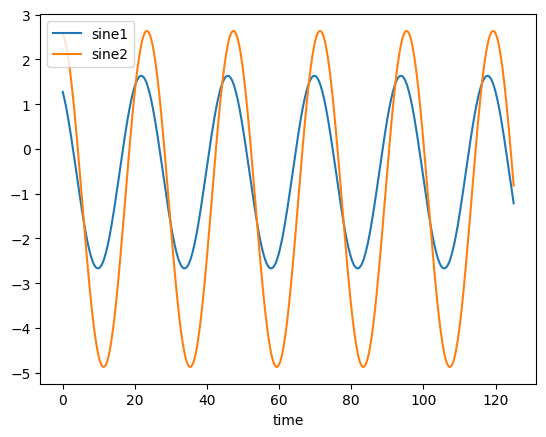

In [ ]:
sine_df.plot(x = 'time')

## Bayesian Inference on Sinusoids

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0, r, A = ode_resid_unflatten(theta, N)

    return odeint(func=gLV, y0=X0,
                  t=time,
                  args=(r, A,))


In [ ]:
n = 2
with pm.Model() as model:

    priors = []

    # Params for X0
    for i in range(n):

      prior = pm.Normal(f"x{i}", 0, 5)
      priors.append(prior)

    # Params for r
    for i in range(n):

      prior = pm.Normal(f"r{i}", 0, 2)
      priors.append(prior)

    # Params for A
    for k in range(n * n):
      # row and column indexes
      i, j = k // n, k % n

      prior = pm.Normal(f"A({i}, {j})", 0, 2)
      priors.append(prior)

    # Standard Deviation Prior
    sigma = pm.HalfNormal("sigma", 3)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=sine_df[["sine1", "sine2"]].values)

In [ ]:
# Variable list to give to the sample step parameter
vars_sine_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sine_sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    # sine_trace_slice = pm.sample(step = pm.Slice(vars_sine_list),
    #                              tune = tune,
    #                              draws = draws)
    sine_trace_slice = pm.sample(tune=tune,
                                 step=[pm.Slice(vars_sine_list)],
                                 draws=draws,
                                 nuts_sampler = "pymc")

sine_trace = sine_trace_slice
sine_trace_summary = az.summary(sine_trace)
sine_trace_summary

Output()

<ipython-input-59-441a4e088e1b>:8: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with
full_output = 1 to get quantitative information.
  return odeint(func=gLV, y0=X0,

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"A(0, 0)",-0.041,0.039,-0.095,0.012,0.027,0.006,2.0,13.0,2.42
"A(0, 1)",0.103,0.040,0.055,0.155,0.028,0.002,3.0,21.0,1.86
"A(1, 0)",-0.839,0.396,-1.465,-0.404,0.274,0.063,3.0,17.0,2.13
"A(1, 1)",0.019,0.021,-0.009,0.049,0.014,0.003,2.0,11.0,2.87
r0,0.111,0.057,0.048,0.195,0.040,0.008,2.0,11.0,2.90
r1,-0.425,0.107,-0.595,-0.298,0.074,0.014,3.0,13.0,2.15
sigma,1.639,0.198,1.393,1.895,0.137,0.001,3.0,70.0,1.83
x0,-0.621,0.138,-0.892,-0.459,0.090,0.042,3.0,16.0,2.20
x1,-0.212,0.153,-0.412,-0.031,0.106,0.005,3.0,19.0,1.94


## Reproduce waves

In [ ]:
sine_bayes_params = sine_trace_summary.loc[['x0', 'x1', 'r0', 'r1',
                                            'A(0, 0)', 'A(0, 1)', 'A(1, 0)',
                                            'A(1, 1)']
                                           , 'mean'].values

X0_sine_bayes, r_sine_bayes, A_sine_bayes = ode_resid_unflatten(sine_bayes_params, 2)

<Axes: xlabel='time'>

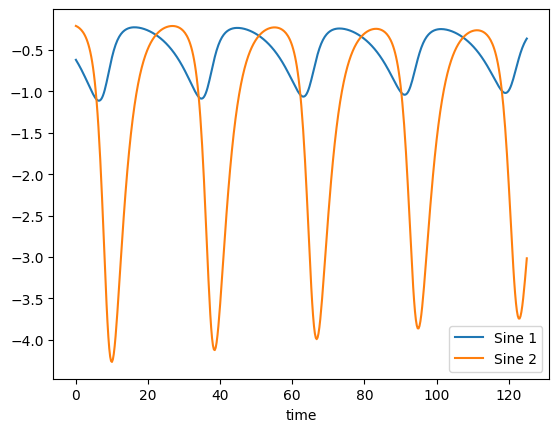

In [ ]:
sine_bayes_sol = odeint(func = gLV,
                         y0   = X0_sine_bayes,
                         t    = time,
                         args = (r_sine_bayes, A_sine_bayes))

sine_bayes_sol = pd.DataFrame(sine_bayes_sol)
sine_bayes_sol.columns = ['Sine 1', 'Sine 2']
sine_bayes_sol.index = time
sine_bayes_sol = sine_bayes_sol\
  .reset_index()\
  .rename(columns = {'index':'time'})
sine_bayes_sol.plot(x = 'time')
# 10K draws

## Least Squares on Sines

In [ ]:
def ode_model_resid(params):
    """
    params : flattened vector of X0, r, and A.
    returns : flattened vector of residuals after applying least squares
    """
    X0, r, A = ode_resid_unflatten(params, 2)
    # theta = np.concatenate((X0, r
    # y0 = theta[-2:]
    # r = np.array([theta[0], -theta[2]])
    # A = np.array([[0, -theta[1]], [theta[3], 0]])

    sol = odeint(func=gLV,
                 y0=X0,
                 t=time,
                 args=(r, A,))

    return (
        sine_df[["sine1", "sine2"]] - sol
    ).values.flatten()

<ipython-input-38-d45d3b84db56>:12: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(func=gLV,


<Axes: xlabel='time'>

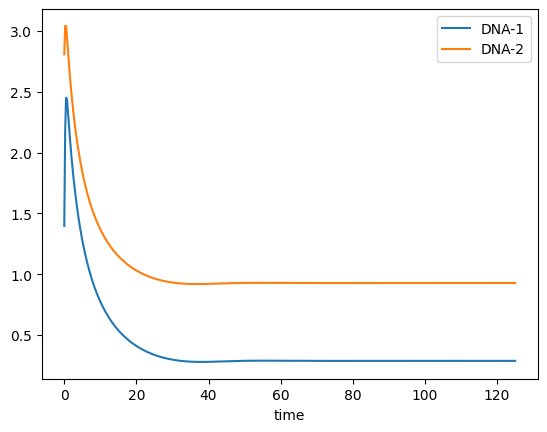

In [ ]:
theta = np.array([26, 10, 0.52, 0.026, 0, -0.84, 0.026, 0])

# calculate least squares using the Scipy solver
results_glv2 = least_squares(ode_model_resid, x0=theta)

# Get params
X0_sine_ls, r_sine_ls, A_sine_ls = ode_resid_unflatten(results_glv2.x, 2)

# Generate sinusoid from LS params
sine_bayes_sol = odeint(func = gLV,
                         y0   = X0_sine_ls,
                         t    = time,
                         args = (r_sine_ls, A_sine_ls))

sine_least_sol = pd.DataFrame(sine_bayes_sol)
sine_least_sol.columns = ['DNA-1', 'DNA-2']
sine_least_sol.index = time
sine_least_sol = sine_least_sol\
  .reset_index()\
  .rename(columns = {'index':'time'})
sine_least_sol.plot(x = 'time')

<Axes: xlabel='time'>

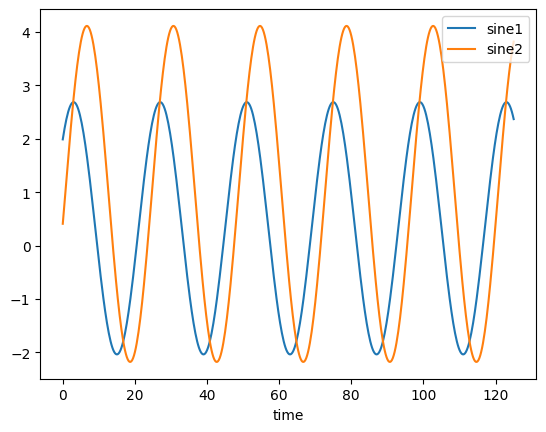

In [ ]:
sine_df.plot(x = 'time')

# Sample 2 Dinner Waveforms

## Data Transformations

<Axes: xlabel='time'>

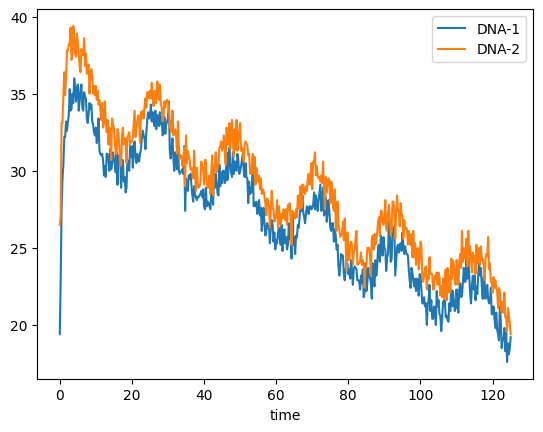

In [ ]:
dna12_df = dinner_df[['time', 'DNA-1', 'DNA-2']]

dna12_df.plot(x = 'time')

<Axes: xlabel='time'>

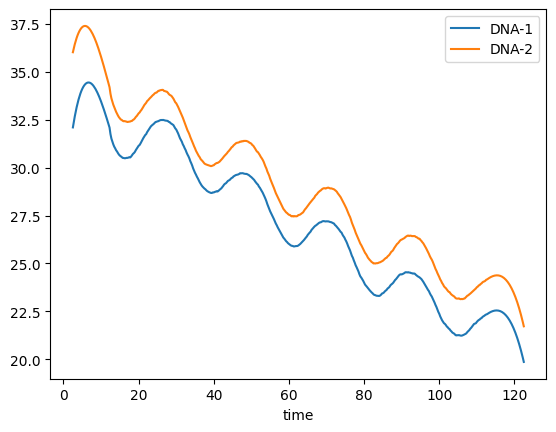

In [ ]:
window_length = 100
polyorder = 3

dna12_smooth = dna12_df.copy()
dna12_smooth['DNA-1'] = savgol_filter(dna12_smooth['DNA-1'],
                                      window_length = window_length,
                                      polyorder = polyorder)

dna12_smooth['DNA-2'] = savgol_filter(dna12_smooth['DNA-2'],
                                   window_length = window_length,
                                   polyorder = polyorder)

dna12_smooth = dna12_smooth.iloc[10:-10, :]

dna12_smooth.plot(x = 'time')

<Axes: xlabel='time'>

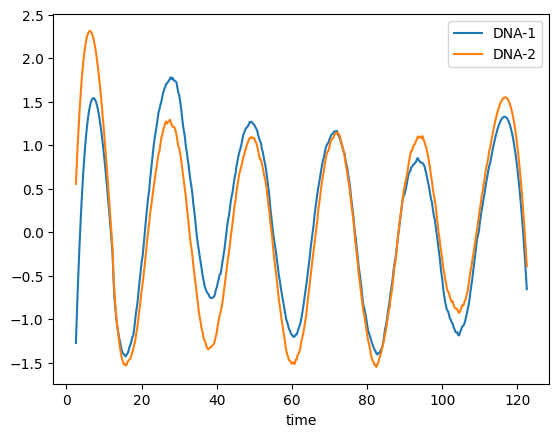

In [ ]:
window_length = 100
polyorder = 3

dna12_det = dna12_df.copy()
dna12_det['DNA-1'] = detrend(dna12_det['DNA-1'])
dna12_det['DNA-1'] = savgol_filter(dna12_det['DNA-1'],
                                   window_length = window_length,
                                   polyorder = polyorder)

dna12_det['DNA-2'] = detrend(dna12_det['DNA-2'])
dna12_det['DNA-2'] = savgol_filter(dna12_det['DNA-2'],
                                   window_length = window_length,
                                   polyorder = polyorder)

dna12_det = dna12_det.iloc[10:-10, :]

dna12_det.plot(x = 'time')

In [ ]:
dna12_det['DNA-1'].dtype

dtype('float64')

## Dinner Priors

In [ ]:
# note theta = alpha, beta, gamma, delta, xt0, yt0
alpha = 0.52
beta = 0.026
gamma = 0.84
delta = 0.026
xt0 = -13.0
yt0 = -8.9

r_dna12_sim = np.array([alpha, -gamma])
A_dna12_sim = np.array([[0, -beta], [delta, 0]])
X0_dna12_sim = np.array([xt0, yt0])
# r_dna12_sim = np.random.normal(size = (2, ))
# A_dna12_sim = np.random.normal(size = (2, 2))
# X0_dna12_sim = dna12_det.values[0, 1:]

X0_dna12_sim, r_dna12_sim, A_dna12_sim = ode_resid_unflatten(np.array([34.0, 5.9, 0.52, 0, -0.84, 0.026, 0.026, 0]), n = 2)

# theta = np.array([alpha, beta, gamma, delta, xt0, yt0])
time = dna12_det['time'].values

## Least Squares

In [ ]:
# calculate least squares using the Scipy solver
theta_dna12 = ode_resid_flatten(X0_dna12_sim,
                                r_dna12_sim,
                                A_dna12_sim)
results_dna12 = least_squares(ode_model_resid,
                              x0=theta_dna12)
dna12_lq = ode_resid_unflatten(params = results_dna12.x,
                               n = X0_dna12_sim.shape[0])
X0_dna12_lq, r_dna12_lq, A_dna12_lq = dna12_lq

NameError: name 'X0_dna12_sim' is not defined

In [ ]:
dna12_lq_params = {}
temp = ode_resid_unflatten(results_dna12.x, n = N)
dna12_lq_params['X0'] = temp[0]
dna12_lq_params['r'] = temp[1]
dna12_lq_params['A'] = temp[2]
dna12_lq_params

{'X0': array([34.00000001,  5.90000004]),
 'r': array([5.20000071e-01, 4.86091363e-08]),
 'A': array([[-8.40000480e-01,  2.59996162e-02],
        [ 2.59999755e-02, -1.96126023e-06]])}

<ipython-input-96-d040aebeb113>:1: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  dna12_lq_sol = odeint(func = gLV,


<Axes: xlabel='time'>

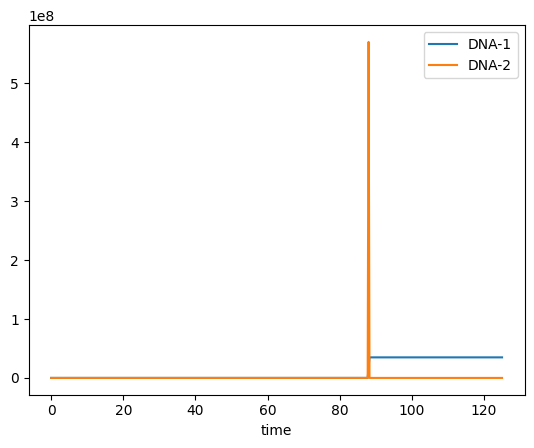

In [ ]:
dna12_lq_sol = odeint(func = gLV,
                      y0 = dna12_lq_params['X0'],
                      t    = time,
                      args = (dna12_lq_params['r'], dna12_lq_params['A']))

dna12_lq_sol = pd.DataFrame(dna12_lq_sol)
dna12_lq_sol.columns = ['DNA-1', 'DNA-2']
dna12_lq_sol.index = time
dna12_lq_sol = dna12_lq_sol.reset_index().rename(columns = {'index':'time'})
dna12_lq_sol
dna12_lq_sol.plot(x = 'time')

<Axes: xlabel='time'>

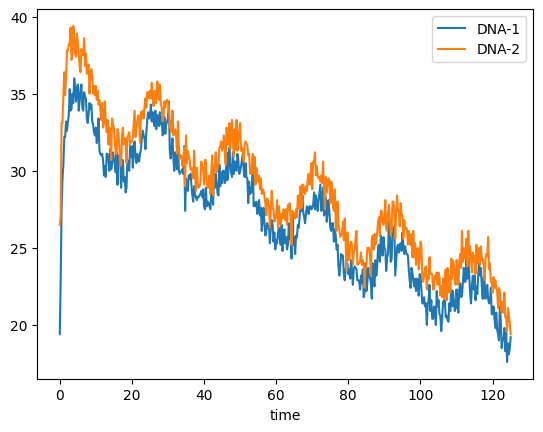

In [ ]:
dna12_df.plot(x = 'time')

## Bayesian Inference

In [ ]:
time = dna12_det['time'].values

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0, r, A = ode_resid_unflatten(theta, 2)

    return odeint(func=gLV, y0=X0,
                  t=dna12_smooth.time,
                  args=(r, A,))


In [ ]:
dna12_det.shape

(501, 3)

<Axes: xlabel='time'>

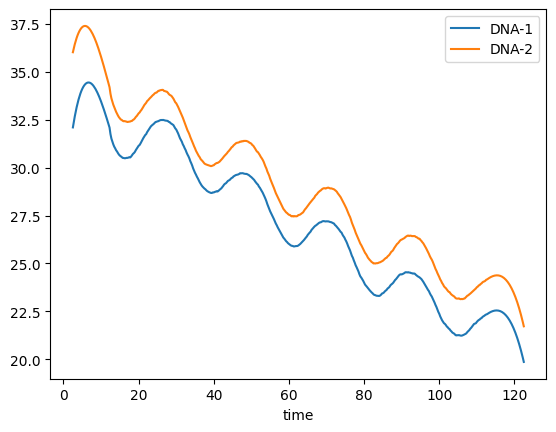

In [ ]:
dna12_smooth.plot(x = 'time')

In [ ]:
n = 2
with pm.Model() as model:
  priors = []

  # Params for X0
  for i in range(n):
    prior = pm.Uniform(f"x{i}", 10, 40)
    priors.append(prior)

  # Params for r
  for i in range(n):
    prior = pm.Normal(f"r{i}", 0, 3)
    priors.append(prior)

  # Params for A
  for k in range(n * n):
    # row and column indexes
    i, j = k // n, k % n

    prior = pm.Normal(f"A({i}, {j})", 0, 3)
    priors.append(prior)

  # Standard Deviation Prior
  sigma = pm.HalfNormal("sigma", 2)

  # Ode solution function for Lotka-Volterra
  ode_solution = pytensor_forward_model_matrix(
      pm.math.stack(priors)
  )

  # Likelihood
  pm.Normal("Y_obs",
            mu=ode_solution,
            sigma=sigma,
            observed=dna12_smooth[["DNA-1", "DNA-2"]].values)

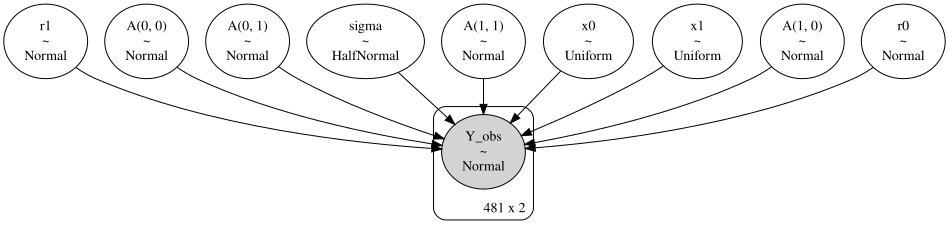

In [ ]:
pm.model_to_graphviz(model=model)

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    trace_slice = pm.sample(tune=tune,
                            step=[pm.Slice(vars_list)],
                            draws=draws)

trace = trace_slice
trace_summary = az.summary(trace)
trace_summary

Output()

<ipython-input-18-7e6d8b4d7e12>:8: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with
full_output = 1 to get quantitative information.
  return odeint(func=gLV, y0=X0,

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"A(0, 0)",0.000,0.000,0.000,0.000,0.000,0.000,3.0,13.0,2.03
"A(0, 1)",-0.000,0.000,-0.000,0.000,0.000,0.000,3.0,14.0,2.00
"A(1, 0)",-0.000,0.000,-0.000,0.000,0.000,0.000,3.0,11.0,2.21
"A(1, 1)",-0.000,0.000,-0.000,0.000,0.000,0.000,3.0,11.0,2.21
r0,-0.006,0.000,-0.007,-0.005,0.000,0.000,3.0,16.0,1.68
r1,-0.002,0.001,-0.003,-0.001,0.000,0.000,3.0,14.0,1.82
sigma,0.932,0.021,0.891,0.969,0.000,0.001,2260.0,1194.0,1.00
x0,33.951,0.114,33.749,34.172,0.034,0.006,11.0,42.0,1.14
x1,36.387,0.136,36.144,36.650,0.059,0.008,5.0,39.0,1.30


In [ ]:
dna12_bayes_params = trace_summary.loc[['x0', 'x1', 'r0', 'r1',
                                        'A(0, 0)', 'A(0, 1)', 'A(1, 0)',
                                        'A(1, 1)'], 'mean'].values

X0_dna12_bayes, r_dna12_bayes, A_dna12_bayes = ode_resid_unflatten(dna12_bayes_params, 2)

<Axes: xlabel='time'>

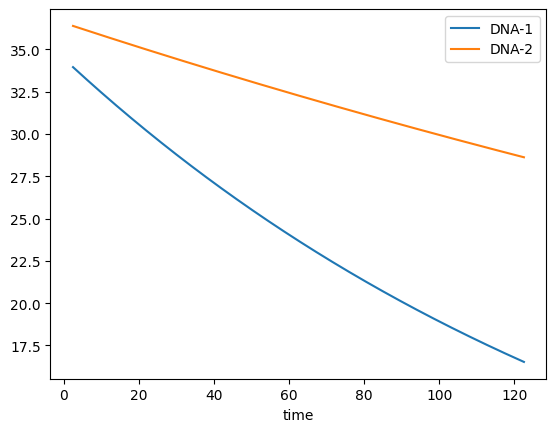

In [ ]:
dna12_bayes_sol = odeint(func = gLV,
                         y0   = X0_dna12_bayes,
                         t    = time,
                         args = (r_dna12_bayes, A_dna12_bayes))

dna12_bayes_sol = pd.DataFrame(dna12_bayes_sol)
dna12_bayes_sol.columns = ['DNA-1', 'DNA-2']
dna12_bayes_sol.index = time
dna12_bayes_sol = dna12_bayes_sol.reset_index().rename(columns = {'index':'time'})
dna12_bayes_sol
dna12_bayes_sol.plot(x = 'time')
# 10K draws

# All Dinner Waveforms

In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_wo_time = dinner_df.drop(columns = ['time'])

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


<Axes: xlabel='time'>

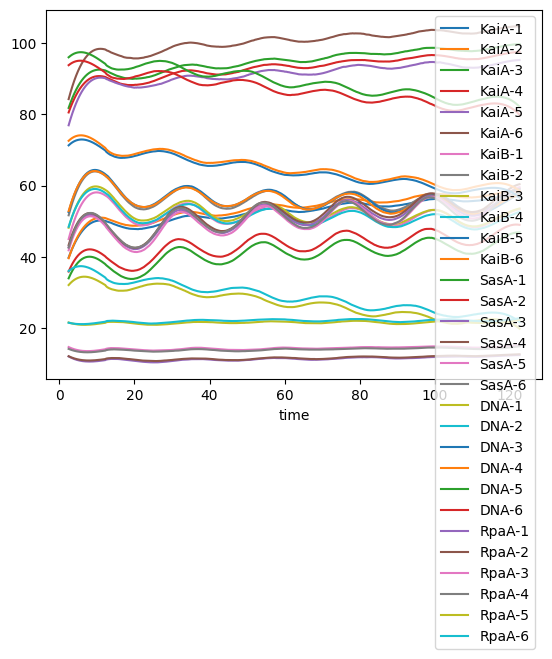

In [ ]:
window_length = 100
polyorder = 3

dinner_smooth = dinner_df.copy()
dinner_smooth[dinner_smooth.columns[1:]] = savgol_filter(dinner_smooth[dinner_smooth.columns[1:]].T,
                                                     window_length = 100,
                                                     polyorder = 3).T

dinner_smooth = dinner_smooth.iloc[10:-10, :]

dinner_smooth.plot(x = 'time')

In [ ]:
from numba import njit

@njit
def gLV(X, t, r, A):
    return X * (r + A @ X)

def ode_resid_flatten(X0, r, A):

    """
    Takes the X0 (n, 1), r (n, 1), A (n, n) and flattens and
    concatenates
     into one array of size (n + n + n * n)

    Function that calculates residuals based on a given theta
    """
    params = np.concatenate((X0, r, A.flatten()))
    return params

def ode_resid_unflatten(params,
                        n = dinner_smooth.shape[1] - 1):
    """
    Reverses ode_resid_flatten from flattened to X0, r, A
    """

    X0 = params[:n]
    r = params[n:2*n]
    A = params[2*n:].reshape((n, n))

    return X0, r, A


def ode_model_resid(params):
    """
    params : flattened vector of X0, r, and A.
    returns : flattened vector of residuals after applying least squares
    """
    X0, r, A = ode_resid_unflatten(params, 2)

    sol = odeint(func=gLV,
                 y0=X0,
                 t=time,
                 args=(r, A,))

    return (
        dinner_smooth.iloc[:, 1:] - sol
    ).values.flatten()

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0, r, A = ode_resid_unflatten(theta, 2)

    return odeint(func=gLV, y0=X0,
                  t=dinner_smooth.time,
                  args=(r, A,))


In [ ]:
n = dinner_smooth.shape[1] -1
with pm.Model() as model:

    priors = []

    # Params for X0
    for i in range(n):

      prior = pm.Uniform(f"x{i}", 0, 40)
      priors.append(prior)

    # Params for r
    for i in range(n):

      prior = pm.Normal(f"r{i}", 0, 3)
      priors.append(prior)

    # Params for A
    for k in range(n * n):
      # row and column indexes
      i, j = k // n, k % n

      prior = pm.Normal(f"A({i}, {j})", 0, 3)
      priors.append(prior)

    # Standard Deviation Prior
    sigma = pm.HalfNormal("sigma", 3)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=dinner_smooth.iloc[:, 1:].values)

In [ ]:
pm.model_to_graphviz(model=model)

In [ ]:
# Variable list to give to the sample step parameter
all_vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
all_tune = all_draws = 100

# Inference!
with model:
    all_trace_slice = pm.sample(tune=all_tune,
                                step=[pm.Slice(all_vars_list)],
                                draws=all_draws,
                                init = "adapt_diag",
                                progressbar=True,
                                cores=4,
                                chains=1)

all_trace = all_trace_slice
all_trace_summary = az.summary(all_trace)
all_trace_summary

KeyboardInterrupt: 

## Matricized

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


<Axes: xlabel='time'>

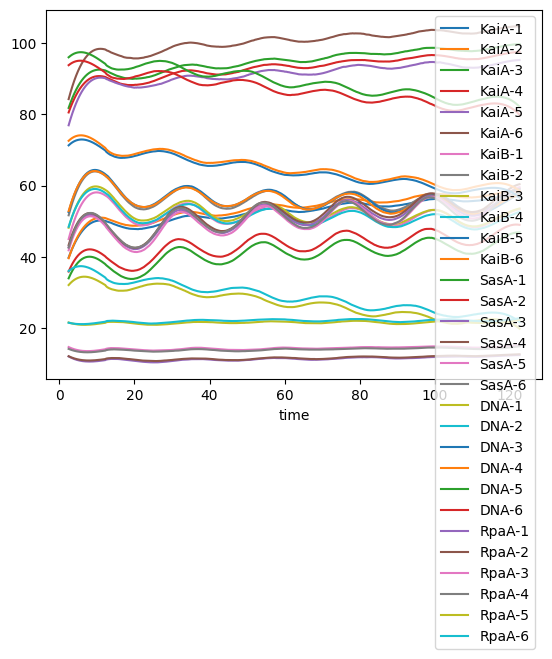

In [ ]:
window_length = 100
polyorder = 3

dinner_smooth = dinner_df.copy()
dinner_smooth[dinner_smooth.columns[1:]] = savgol_filter(dinner_smooth[dinner_smooth.columns[1:]].T,
                                                     window_length = 100,
                                                     polyorder = 3).T

dinner_smooth = dinner_smooth.iloc[10:-10, :]

dinner_smooth.plot(x = 'time')

In [ ]:
def gLV(X, t, r, AX, M):
    return X * (r + AX) + M

# decorator with input and output types a Pytensor double float tensors
# @as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])
@as_op(itypes=[pt.dmatrix], otypes=[pt.dmatrix])
def pytensor_forward_model_matrix(theta):

    X0 = theta[0, :]
    r = theta[1, :]
    AX = theta[2, :]
    M = theta[3, :]

    return odeint(func=gLV, y0=X0,
                  t=dinner_smooth.time,
                  args=(r, AX, M))



In [ ]:
n = dinner_smooth.shape[1] -1
with pm.Model() as model:

  priors = []

  # Params for X0
  X0_prior = pm.Uniform(name = "X0", lower = 0, upper = 40, shape = n)

  priors.append(X0_prior)

  # Params for r
  r_prior = pm.Normal(name = "r", mu = 0, sigma = 3, shape = n)
  priors.append(r_prior)

  # Params for A
  A_prior = pm.Normal(name = "A", mu = 0, sigma = 3, shape = (n, n))
  # priors.append(A_prior)

  AX_prior = pm.Deterministic(name = "Xdot", var = (A_prior @ X0_prior))
  priors.append(AX_prior)

  # Params for slope M
  M_prior = pm.Normal(name = "M", mu = 0, sigma = 3, shape = n)
  priors.append(M_prior)

  # Standard Deviation Prior
  sigma = pm.HalfNormal("sigma", 3)

  # Ode solution function for Lotka-Volterra
  ode_solution = pytensor_forward_model_matrix(
    pm.math.stack(priors)
  )

  # Likelihood
  pm.Normal("Y_obs",
            mu=ode_solution,
            sigma=sigma,
            observed=dinner_smooth.iloc[:, 1:].values)

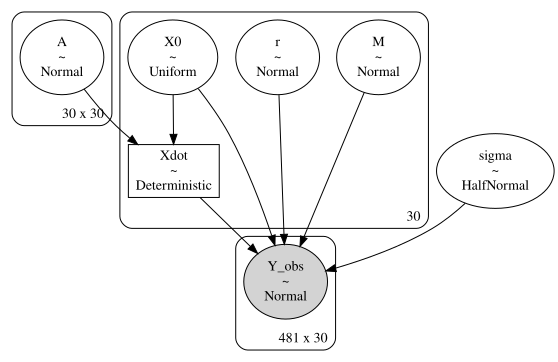

In [ ]:
pm.model_to_graphviz(model=model)

In [ ]:
# Variable list to give to the sample step parameter
all_vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
all_tune = all_draws = 100

# Inference!
with model:
    all_trace_slice = pm.sample(tune=all_tune,
                                step=[pm.Metropolis(all_vars_list)],
                                draws=all_draws,
                                nuts_sampler='pymc',
                                init = "adapt_diag", progressbar=True, cores=4)

all_trace = all_trace_slice
all_trace_summary = az.summary(all_trace)
all_trace_summary

NameError: name 'model' is not defined